In [1]:
from scipy.stats import qmc
import numpy as np
import pandas as pd

from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.gaussian_process.kernels import Matern

In [2]:
#Function 2
#Extracting updated data and turning it into a pandas dataframe
data = pd.read_csv('Data/Week 6 - Function 2.csv') 
columns = ['Input 1', 'Input 2', 'Outputs']
#Remove columns with NaN values
data = data.dropna(axis = 1)
data.columns = columns
#Add Week 7's data to our pandas dataframe
new_data7 = np.array([0.713573, 0.445985, 0.6157097213349471])
data.loc[len(data)] = new_data7
#Add Week 8's data to our pandas dataframe
new_data8 = np.array([0.734435, 0.506061, 0.393451984])
data.loc[len(data)] = new_data8

#Add Week 9's data to our pandas dataframe
new_data9 = np.array([0.666793, 0.462029, 0.4671094381976445])
data.loc[len(data)] = new_data9
#Add Week 10's data to our pandas dataframe
new_data10 = np.array([0.691329, 0.884581, 0.6011979340999474])
data.loc[len(data)] = new_data10
#Add Week 11's data to our pandas dataframe 
new_data11 = np.array([0.708254, 0.378104, 0.6552002854158213])
data.loc[len(data)] = new_data11
data

,Input 1,Input 2,Outputs
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


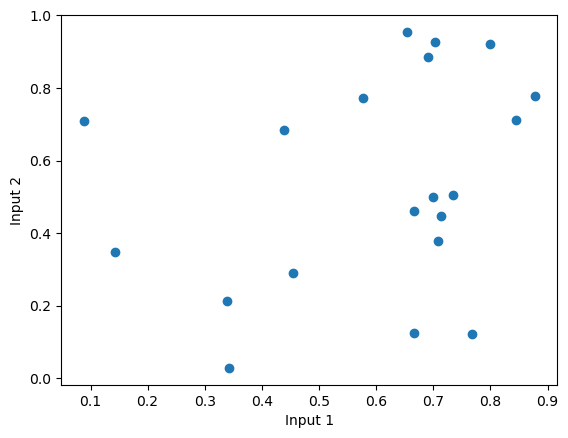

In [4]:
#Extract the Data Into Numpy Arrays
X = np.array(data[['Input 1', 'Input 2']])
Y = np.array(data[['Outputs']])
#Visualise explored points
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:,1])
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.show()

In [4]:
#Using latin hypercube sampling to initialise a set of candidate points in a trust region
#Initialise points in the unit hypercube
d = 2
n = 10000
sampler = qmc.LatinHypercube(d, seed = 42)
grid = sampler.random(n) 

#Scale points generated in the unit hypercube to be inside trust region
#Trust hypercube of radius delta centered at best point with from observed data is 
#[x_best-delta, x_best_plus]
x_best = X[np.argmax(Y)]
#Set radius of hypercube
delta = 0.2
#lower and upper bounds of hypercube
lb = x_best-delta 
ub = x_best+delta

#scale points from unit hypercube to be inside trust region
scaled_grid = lb + grid * (ub-lb) 


NameError: name 'X' is not defined

In [8]:
#We now set the Kernel to be the Matern Kernel
nu = 2.5
kernel = Matern(
    length_scale_bounds=(1e-2, 2),
    nu= nu
)
print("Kernel:", kernel)
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y = True)
print(gp)
gp.fit(X,Y)

mu, std = gp.predict(scaled_grid, return_std = True)

Kernel: Matern(length_scale=1, nu=2.5)
GaussianProcessRegressor(kernel=Matern(length_scale=1, nu=2.5),
                         normalize_y=True)


In [10]:
#Calculate UCB
beta = 0.2 #set exploration parameter
UCB = mu + beta*std 
#Find points that maximises UCB
x_next = scaled_grid[np.argmax(UCB)]
print("Next suggested point:", np.round(x_next,6))


Next suggested point: [0.71688  0.394995]


In [3]:
#Week 12
#Add new data 
new_data = np.array([0.716880, 0.394995, 0.43065061798359583])
data.loc[len(data)] = new_data
data

,Input 1,Input 2,Outputs
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


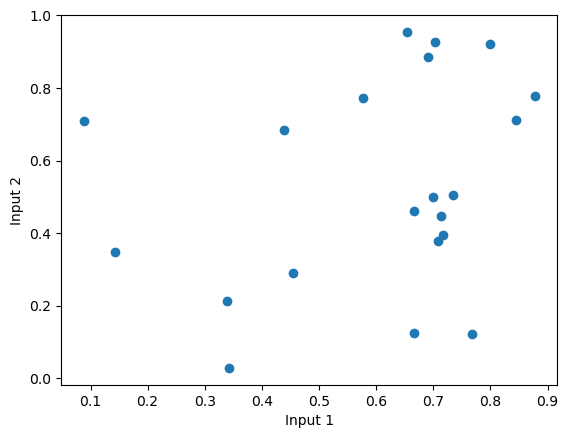

In [6]:
#Extract the Data Into Numpy Arrays
X = np.array(data[['Input 1', 'Input 2']])
Y = np.array(data[['Outputs']])
#Visualise explored points
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:,1])
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.show()

In [11]:
#Using latin hypercube sampling to initialise a set of candidate points in a trust region
#Initialise points in the unit hypercube
d = 2
n = 10000
sampler = qmc.LatinHypercube(d, seed = 42)
grid = sampler.random(n) 

#Scale points generated in the unit hypercube to be inside trust region
#Trust hypercube of radius delta centered at best point with from observed data is 
#[x_best-delta, x_best_plus]
x_best = X[np.argmax(Y)]
#Shrink radius of hypercube to 90% of its orginal size as there was no improvement in previous week 
delta = 0.2*0.9
#lower and upper bounds of hypercube
lb = x_best-delta 
ub = x_best+delta

#scale points from unit hypercube to be inside trust region
scaled_grid = lb + grid * (ub-lb) 
print("Center of hypercube:", x_best)
print("Upper bound", ub)
print("lower bound", lb)

(array([0.888254, 0.558104]), array([0.528254, 0.198104]))

In [9]:
#We now set the Kernel to be the Matern Kernel
nu = 2.5
kernel = Matern(
    length_scale_bounds=(1e-2, 2),
    nu= nu
)
print("Kernel:", kernel)
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y = True)
print(gp)
gp.fit(X,Y)

mu, std = gp.predict(scaled_grid, return_std = True)

Kernel: Matern(length_scale=1, nu=2.5)
GaussianProcessRegressor(kernel=Matern(length_scale=1, nu=2.5),
                         normalize_y=True)


In [13]:
#Calculate UCB
beta = 0.2 #set exploration parameter
UCB = mu + beta*std 
#Find points that maximises UCB
x_next = scaled_grid[np.argmax(UCB)]
print("Next suggested point:", np.round(x_next,6))

Next suggested point: [0.700564 0.369173]


In [4]:
#Week 13
#Add new data 
new_data = np.array([0.700564, 0.369173, 0.575959699604998])
data.loc[len(data)] = new_data
data

,Input 1,Input 2,Outputs
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


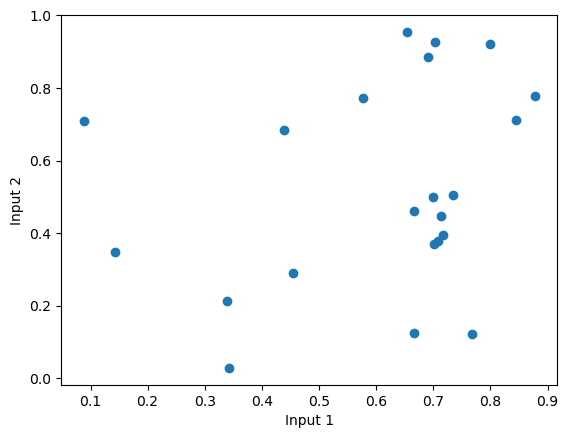

In [5]:
#Extract the Data Into Numpy Arrays
X = np.array(data[['Input 1', 'Input 2']])
Y = np.array(data[['Outputs']])
#Visualise explored points
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:,1])
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.show()

In [6]:
#Using latin hypercube sampling to initialise a set of candidate points in a trust region
#Initialise points in the unit hypercube
d = 2
n = 10000
sampler = qmc.LatinHypercube(d, seed = 42)
grid = sampler.random(n) 

#Scale points generated in the unit hypercube to be inside trust region
#Trust hypercube of radius delta centered at best point with from observed data is 
#[x_best-delta, x_best_plus]
x_best = X[np.argmax(Y)]
#Shrink radius hypercube to 90% of its orginal size as there was no improvement in previous week 
delta = 0.2*0.9*0.9
#lower and upper bounds of hypercube
lb = x_best-delta 
ub = x_best+delta

#scale points from unit hypercube to be inside trust region
scaled_grid = lb + grid * (ub-lb) 
print("Center of hypercube:", x_best)
print("Upper bound", ub)
print("lower bound", lb)

Center of hypercube: [0.708254 0.378104]
Upper bound [0.888254 0.558104]
lower bound [0.528254 0.198104]


In [7]:
#We now set the Kernel to be the Matern Kernel
nu = 2.5
kernel = Matern(
    length_scale_bounds=(1e-2, 2),
    nu= nu
)
print("Kernel:", kernel)
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y = True)
print(gp)
gp.fit(X,Y)

mu, std = gp.predict(scaled_grid, return_std = True)

Kernel: Matern(length_scale=1, nu=2.5)
GaussianProcessRegressor(kernel=Matern(length_scale=1, nu=2.5),
                         normalize_y=True)


In [8]:
#Calculate UCB
beta = 0.2 #set exploration parameter
UCB = mu + beta*std 
#Find points that maximises UCB
x_next = scaled_grid[np.argmax(UCB)]
print("Next suggested point:", np.round(x_next,6))

Next suggested point: [0.710515 0.372081]
